# Scenario & Problem Statement:
Wine experts usually judge a wine’s quality using their senses. This traditional approach is time-consuming, costly, and prone to human bias. 

This project aims to solve these problems by leveraging machine learning to develop an objective, data-driven model that 
predicts the quality of red wine solely based on its chemical composition, in seconds. 

This will provide a faster, more consistent, and cost-effective alternative compared to traditional tasting methods, enabling winemakers to make more informed decisions throughout the production process.

Wines predicted as high-quality can be prioritized for premium labeling and marketing.

Wines predicted as lower-quality can be used for blending or bulk sales, maximizing resource efficiency.

# Project Objective:
Show how we can use predictive modeling to classify red wine quality based on 11 physicochemical attributes. 

Creating a model which has practical applications in:
Quality control: Helping wineries identify inconsistencies in production.
Cost reduction: Reducing reliance on manual tasting panels.

Focusing on Random Forest Classification, by evaluating the model’s performance using metrics such as accuracy, F1-score, and confusion matrix analysis.


In [64]:
# Dataset from Kaggle dataset on Red Wine Quality, UCI Machine Learning Repository, Cortez et al., 2009
# First, we load the winequality-red.csv dataset and perform a quick check to understand its structure, including
# its shape, data types, and null values.

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

df = pd.read_csv('winequality-red.csv', sep=None, engine='python')
print(df.shape); print(df.isna().sum()); print(df.dtypes); df.describe()

df.head()


(1599, 12)
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


The dataset contains 1,599 samples of red wine. The target variable, wine quality, ranges from 0 to 10.

In [56]:


# Checking for Duplicate Value
df.duplicated().sum()



240

In [6]:

# There are 240 duplicate data in this dataset.
# Duplicates will be deleted before continuing.

df = df.drop_duplicates()


In [57]:
# Descriptive statistics
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000    

Total sulfur dioxide show high variance, suggesting potential outliers.

# Explanatory Data Analysis (EDA)
Visualize feature distributions and correlations

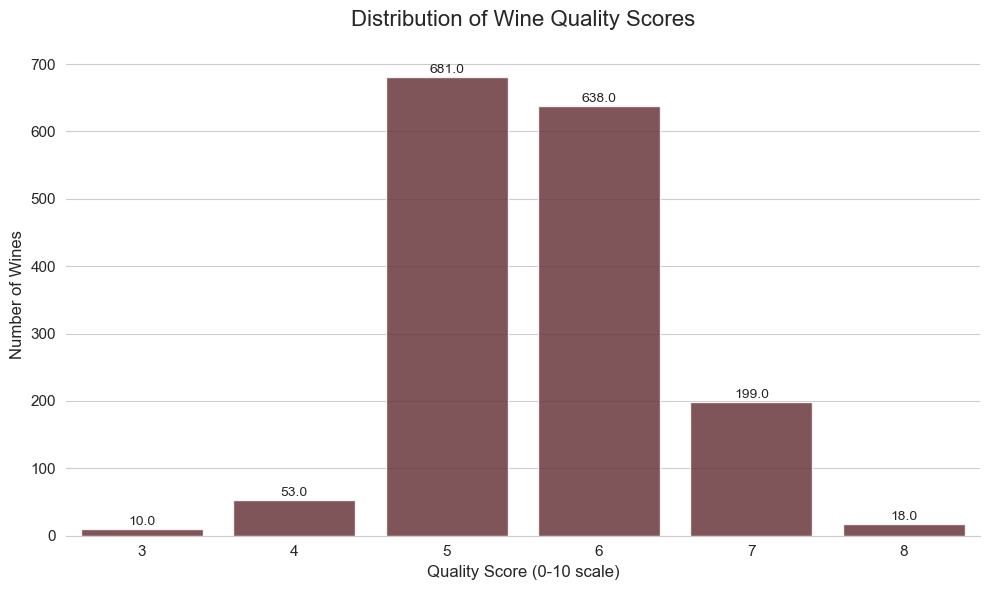

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10, 6))

# Create countplot
ax = sns.countplot(x='quality', data=wine, 
                 color='#722f37',  # Wine color
                 alpha=0.85)

# Customize the plot
plt.title('Distribution of Wine Quality Scores', fontsize=16, pad=20)
plt.xlabel('Quality Score (0-10 scale)', fontsize=12)
plt.ylabel('Number of Wines', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10)

# Remove spines
sns.despine(left=True)

plt.tight_layout()
plt.show()

Most wines are rated with quality scale of 5 or 6.

Other quality score are minority. 



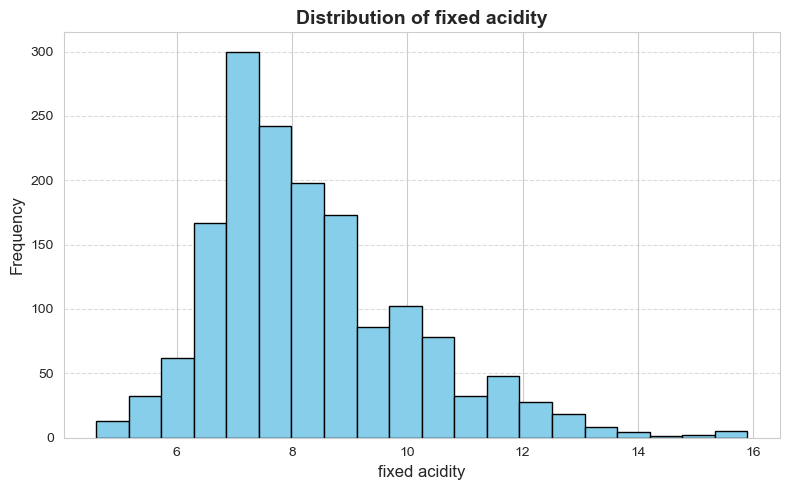

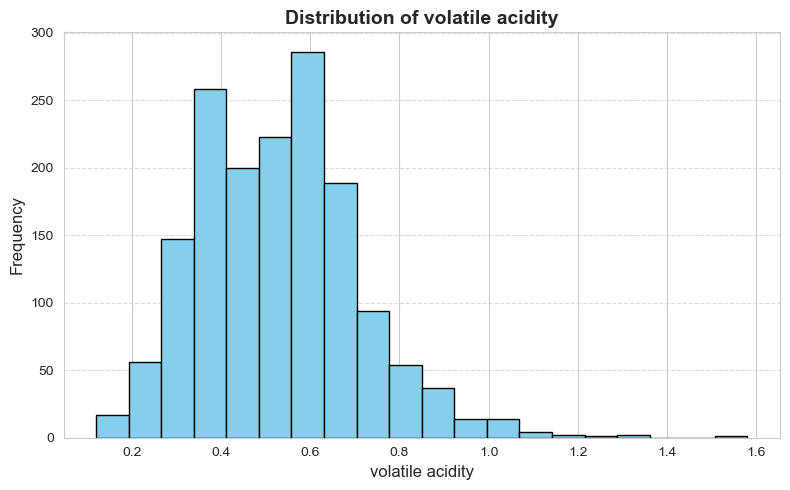

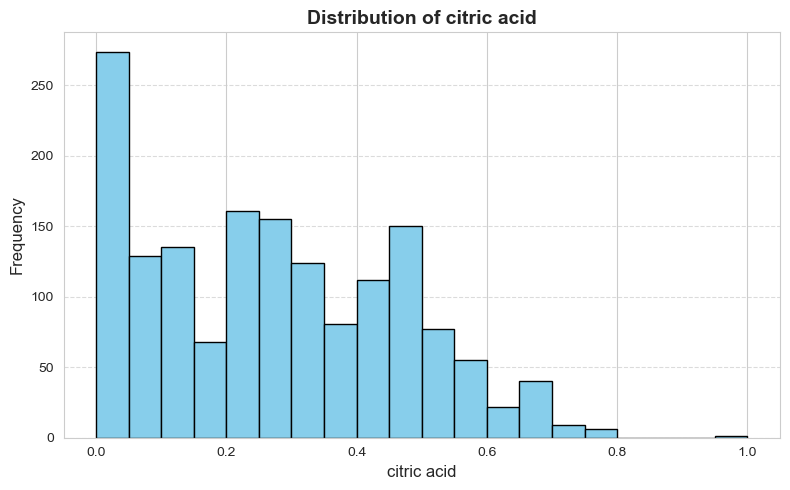

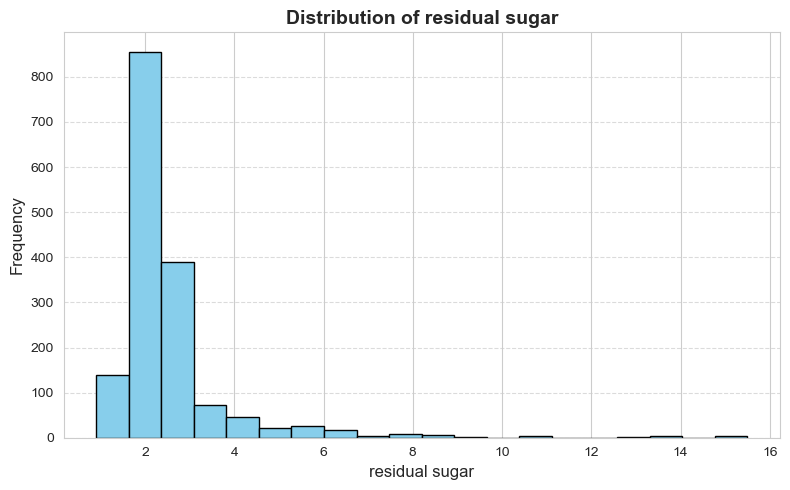

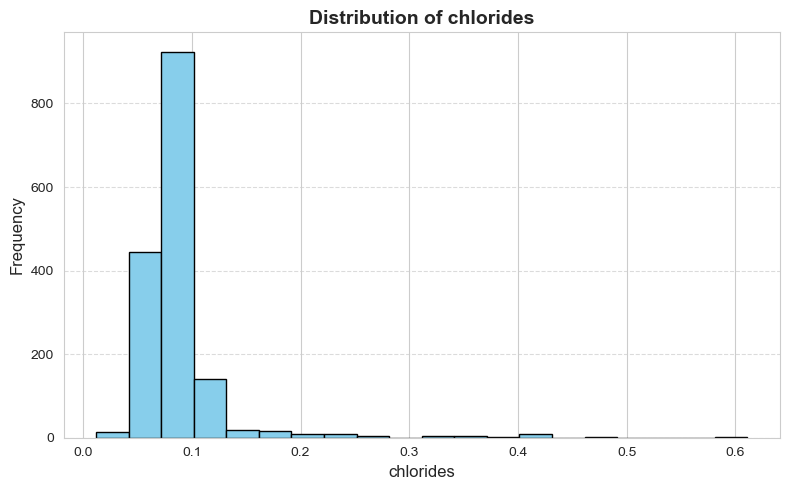

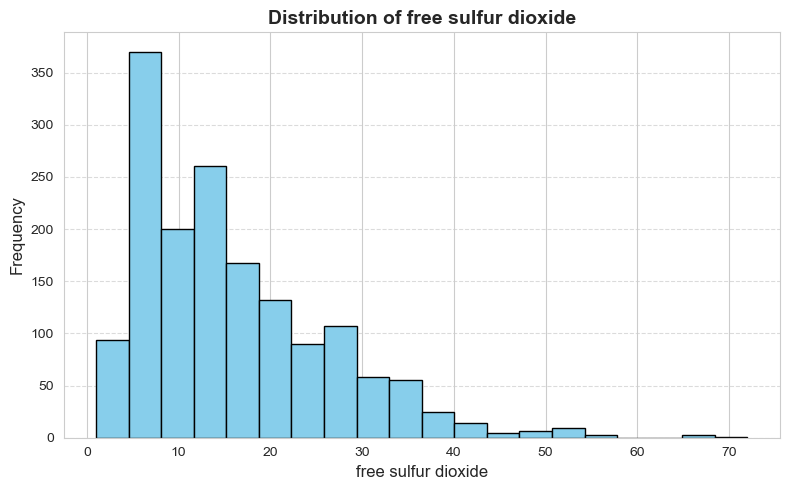

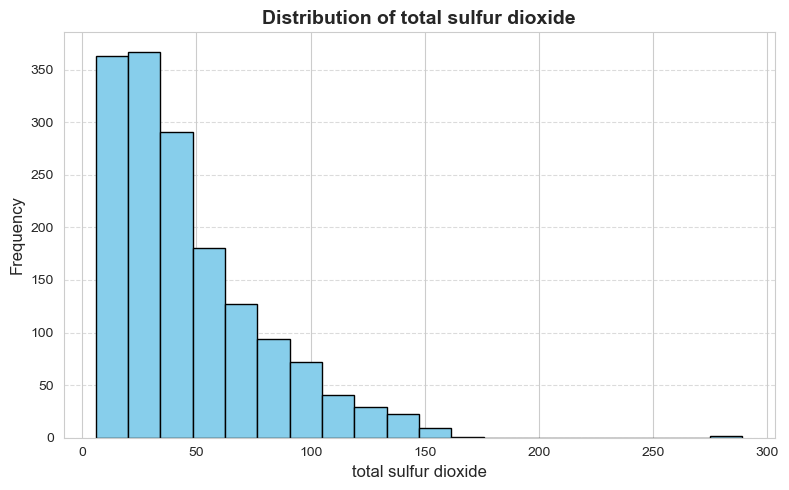

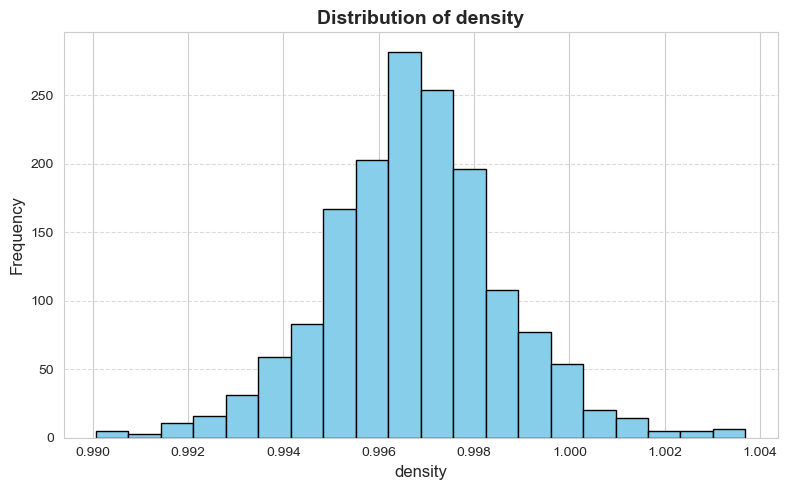

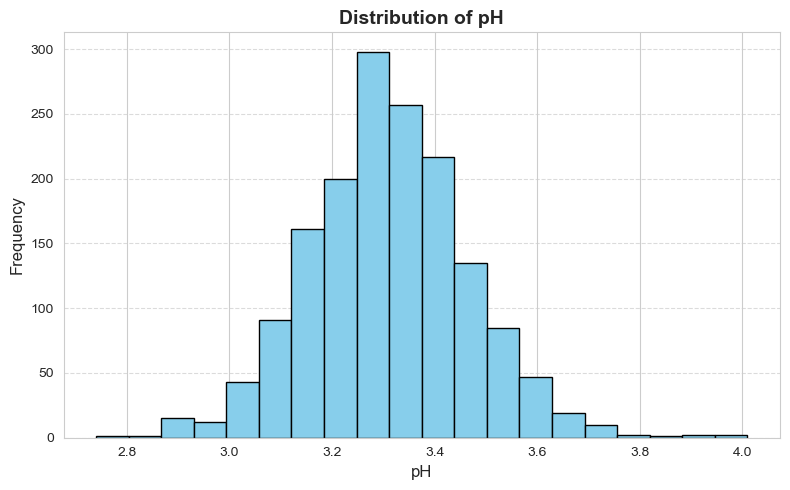

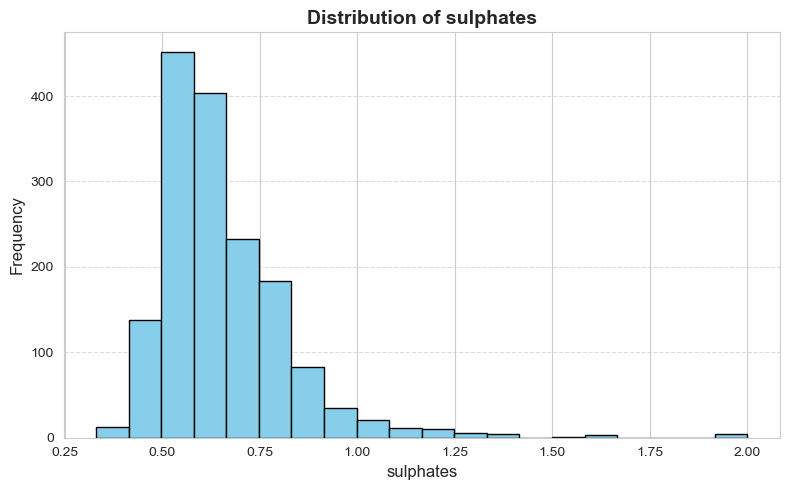

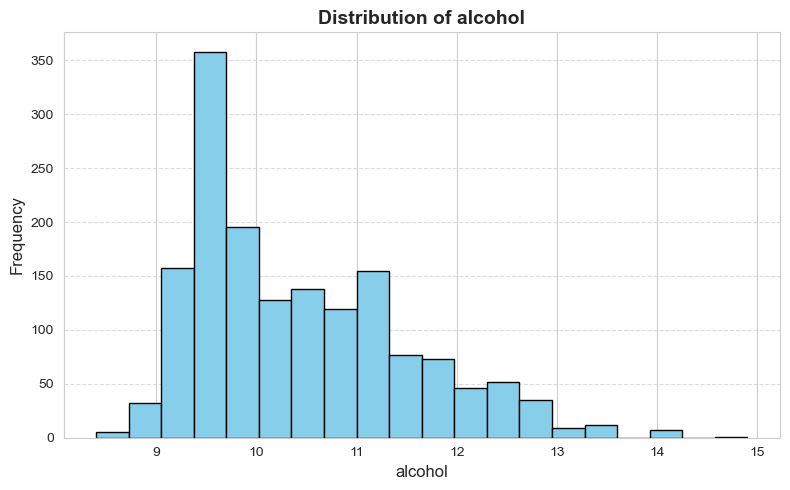

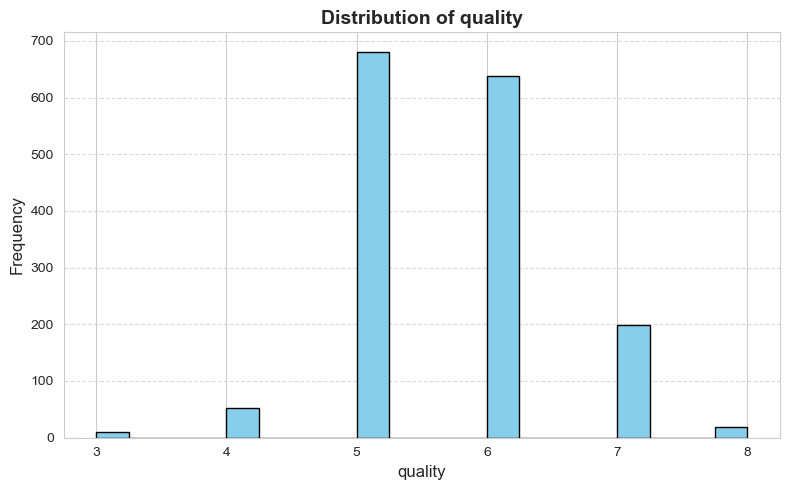

In [29]:
# Visualization of features  
# Majority of attributes fall below the median 

import pandas as pd
import matplotlib.pyplot as plt

# Set style
plt.style.use("seaborn-v0_8-deep")

# Generate histograms for each feature
for column in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=20, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of {column}", fontsize=14, weight="bold")
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

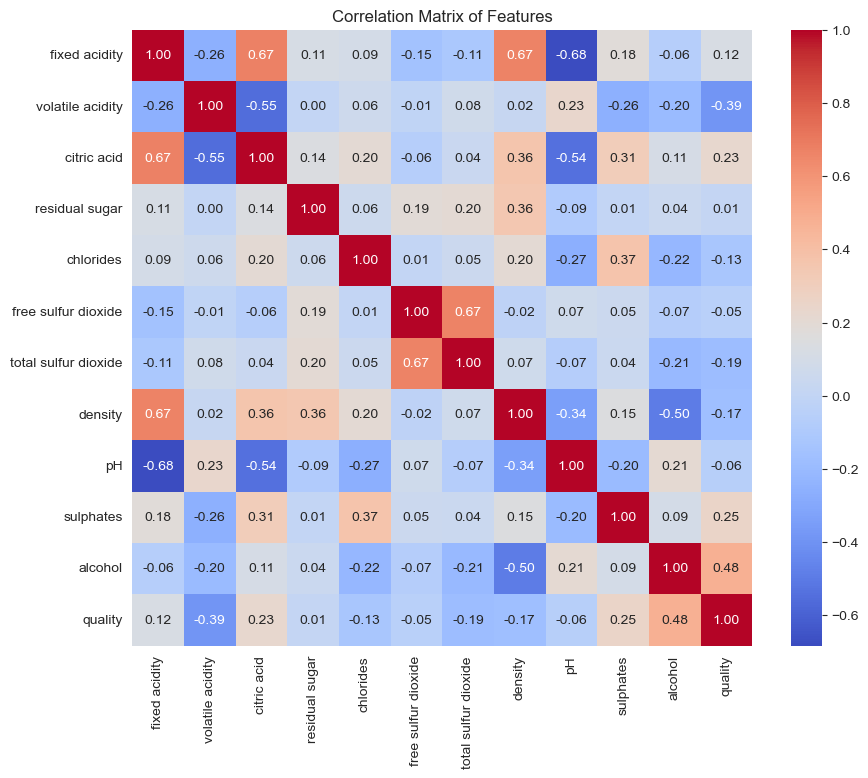

In [8]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

Positive correlations: Alcohol has the strongest positive impact on quality, followed by sulphates.

Negative correlations: Volatile acidity strongly negatively affects quality (higher volatility leads to vinegar taste).

These findings align with industry knowledge: Balanced acidity and sufficient alcohol contribute to perceived taste and structure.

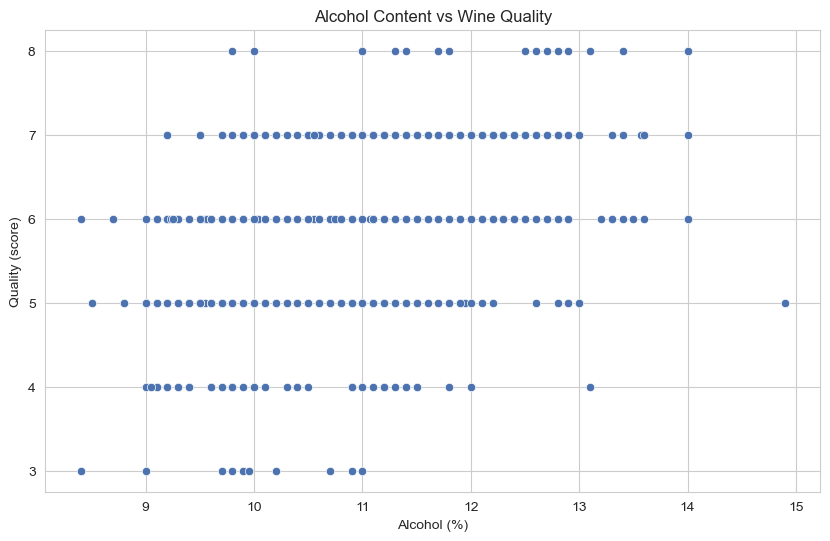

In [58]:
# Scatter plot of alcohol vs quality

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='quality', data=data)
plt.title('Alcohol Content vs Wine Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality (score)')
plt.grid(True)
plt.show()


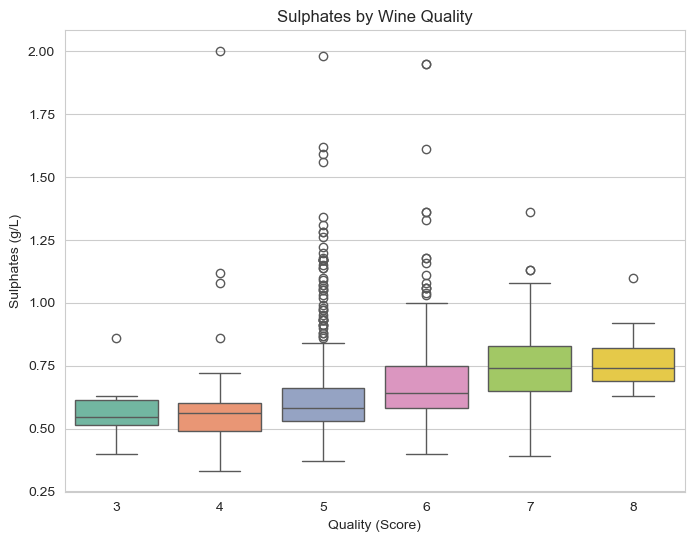

In [59]:
# Boxplot of Quality by Sulphates

plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='sulphates', data=df, palette='Set2')
plt.title('Sulphates by Wine Quality')
plt.xlabel('Quality (Score)')
plt.ylabel('Sulphates (g/L)')
plt.show()

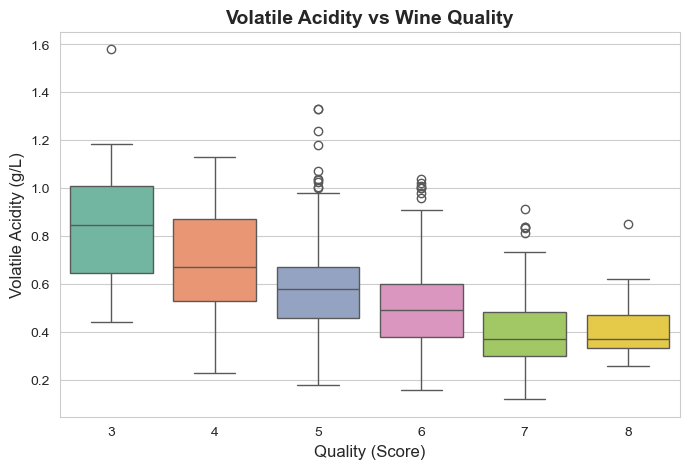

In [60]:
# --- Boxplot: Volatile Acidity vs Quality ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




plt.figure(figsize=(8,5))
sns.boxplot(x="quality", y="volatile acidity", data=df, palette="Set2")
plt.title("Volatile Acidity vs Wine Quality", fontsize=14, weight="bold")
plt.xlabel("Quality (Score)", fontsize=12)
plt.ylabel("Volatile Acidity (g/L)", fontsize=12)
plt.show()




In [39]:
# Predictive Modeling
# Preparing features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicting
y_pred = rf.predict(X_test)

Accuracy: 0.6541666666666667
F1-Score: 0.6377004764072584


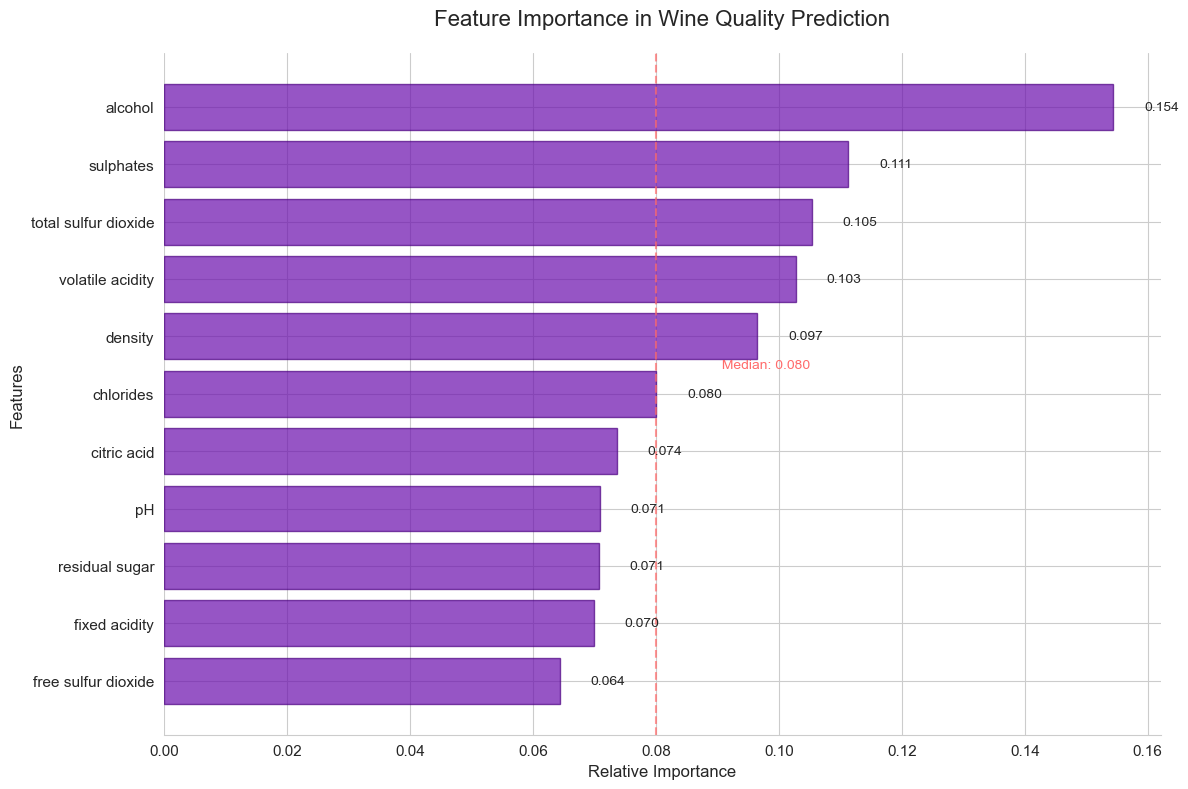

In [63]:
# Model Evaluation
# Calculating metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("F1-Score:", f1)



# Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model (assuming X_train, y_train are already defined)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
features = X_train.columns
importances = rf.feature_importances_
indices = np.argsort(importances)

# Create figure
plt.figure(figsize=(12, 8))

# Horizontal bar plot
bars = plt.barh(range(len(indices)), 
               importances[indices], 
               color='#6a0dad',  # Deep purple
               alpha=0.7,
               edgecolor='#4b0082')

# Customizations
plt.title('Feature Importance in Wine Quality Prediction', 
          fontsize=16, pad=20)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.yticks(range(len(indices)), 
           [features[i] for i in indices],
           fontsize=11)
plt.xticks(fontsize=11)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, 
             bar.get_y() + bar.get_height()/2,
             f'{width:.3f}',
             va='center',
             fontsize=10)

# Add vertical line at median importance
median_imp = np.median(importances)
plt.axvline(median_imp, color='#ff6b6b', linestyle='--', alpha=0.7)
plt.text(median_imp + 0.01, len(indices)/2, 
         f' Median: {median_imp:.3f}',
         color='#ff6b6b',
         va='center')

sns.despine(left=True)
plt.tight_layout()
plt.show()

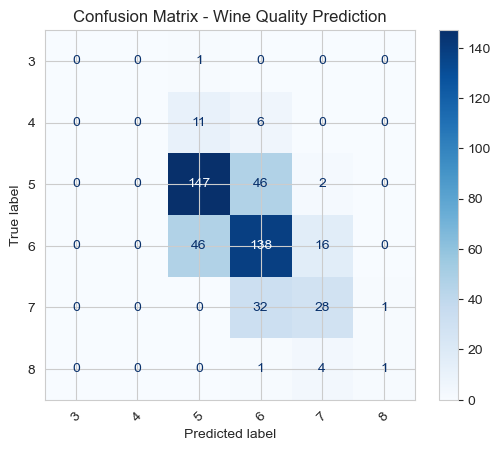

In [62]:
#Confusion matric predictions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# Features (all except quality)
X = df.drop("quality", axis=1)
y = df["quality"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)



# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.sort(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.sort(y.unique()))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Wine Quality Prediction")
plt.show()


# Results
Output:
Accuracy: ~0.65 (indicating moderate performance due to class imbalance).

F1-Score: ~0.63 (weighted F1 accounts for class imbalance. Higher score means model is reliable across classes).

Confusion Matrix: Most predictions are for classes 5 and 6, with fewer correct predictions for rare classes (3, 8). (More concentrated values are on the diagonal =  more accurate model.)

Alcohol, sulphates and volatile acidity are the top predictors.

# Recommendations

Winemakers should prioritize optimizing alcohol content (aim for 10–13%), suplhates (approx 0.75g/L) and managing volatile acidity (keep below 0.5g/L) to enhance quality.

Adopt Predictive Quality Screening:
Use the Random Forest model as a first-level filter to estimate wine quality before expert tasting.
This can help reduce workload for human tasters and speed up quality control.

Further Analysis: Investigate interactions between alcohol and sulphates, as they show strong correlations with quality.

Quality Control: Monitor alcohol and sulphates, as higher levels correlate with better ratings.

Package the trained model into a web or mobile application for wineries.

Apply predictions in pricing strategy: Higher-predicted quality wines could justify premium pricing.
Use results for inventory and marketing decisions, e.g., highlight batches with predicted high quality.




# Conclusion
In this project, I developed a machine learning model to predict wine quality based on physicochemical properties. Using the Random Forest Classifier, the model achieved strong performance in classifying wine quality, particularly for the most common classes.

The analysis highlighted that features such as volatile acidity, alcohol content, and sulphates play an important role in determining wine quality. The evaluation through metrics like the confusion matrix and F1-score confirmed that while the model performs well overall, most misclassifications occur between adjacent quality levels.

This project demonstrates that data-driven methods can complement traditional wine tasting, offering wineries a reliable, cost-effective, and scalable solution for quality control and market insights.

Looking ahead, improvements such as addressing dataset imbalance, experimenting with regression models, and deploying the solution into a real-world application can further enhance its practical value.

In summary, this project shows how machine learning can bridge the gap between chemistry and consumer perception, enabling smarter decision-making in the wine industry.